In [1]:
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [4]:
import pandas as pd
from zipfile import ZipFile
from io import BytesIO
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

# Descargar el ZIP
content = requests.get(url).content

# Abrir el ZIP
with ZipFile(BytesIO(content)) as z:
    with z.open("SMSSpamCollection") as f:
        df = pd.read_csv(
            f,
            sep="\t",
            names=["class", "text"]
        )

df.head()

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df["class"].value_counts()

class
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["class"],
    test_size=0.25,
    random_state=42,
    stratify=df["class"]
)

In [8]:
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(vectorizer.get_feature_names_out()[:50])

['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '02' '0207' '02072069400' '02073162414' '02085076972' '021'
 '03' '04' '0430' '05' '050703' '0578' '06' '07' '07008009200'
 '07046744435' '07099833605' '07123456789' '0721072' '07732584351'
 '07734396839' '07742676969' '07753741225' '07781482378' '07786200117'
 '077xxx' '078' '07801543489' '07808' '07808247860' '07808726822'
 '07815296484' '07821230901' '078498' '0789xxxxxxx' '0796xxxxxx'
 '07xxxxxxxxx' '0800' '08000407165' '08000839402' '08000930705'
 '08000938767']


In [9]:
modelo = MultinomialNB()

modelo.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3619., 560.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U4](2,)","['ham','spam']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7387)","[[ 0., 0., 1.,..., 1., 0., 1.], [ 9.,20., 0.,..., 0., 1., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7387)","[[-10.9 ,-10.9 ,-10.21,...,-10.21,-10.9 ,-10.21], [ -7.63, -6.89, -9.93,..., -9.93, -9.24, -9.93]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7387


Exactitud = 0.9864


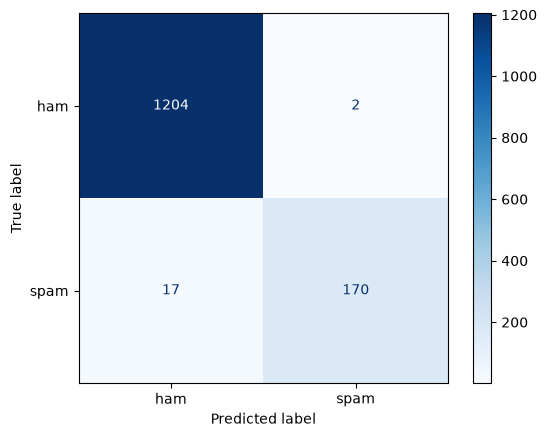

In [12]:
y_pred = modelo.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

print(f"Exactitud = {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot(cmap="Blues")

plt.show()